In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import rasterio
from rasterio.mask import mask
from rasterio.transform import xy as transform_xy

import osmnx as ox
import geopandas as gpd
from shapely.geometry import Polygon
from pyproj import Transformer

import h3


In [41]:
# 1) H3 API 相容（新/舊版 h3 套件）
# ---------------------------
def latlon_to_h3(lat, lon, res: int) -> str:
    # 新版 h3: latlng_to_cell
    if hasattr(h3, "latlng_to_cell"):
        return h3.latlng_to_cell(lat, lon, res)
    # 舊版 h3: geo_to_h3
    return h3.geo_to_h3(lat, lon, res)


def h3_to_polygon(h3_id: str) -> Polygon:
    # 新版 h3: cell_to_boundary 回傳 (lat, lon)
    if hasattr(h3, "cell_to_boundary"):
        boundary = h3.cell_to_boundary(h3_id)  # [(lat, lon), ...]
        return Polygon([(lon, lat) for lat, lon in boundary])
    # 舊版 h3: h3_to_geo_boundary(geo_json=True) 回傳 (lon, lat)
    boundary = h3.h3_to_geo_boundary(h3_id, geo_json=True)  # [(lon, lat), ...]
    return Polygon(boundary)


# ---------------------------
# 2) 輸入：你的 WorldPop tif
# ---------------------------
tif_path = r"Yixing_data\chn_pop_2024_CN_100m_R2025A_v1.tif"

# H3 網格解析度
H3_RES = 7

# 3) 取宜興邊界（OSM）
districts = ox.geocode_to_gdf(["Yixing, Wuxi, Jiangsu, China"]).set_crs("EPSG:4326", allow_override=True)

# 4) 讀 raster + 用邊界裁剪
with rasterio.open(tif_path) as src:
    # 把邊界投影到 raster CRS 才能 mask
    districts_r = districts.to_crs(src.crs)

    out, out_transform = mask(src, districts_r.geometry, crop=True)
    data = out[0].astype(np.float32)

    # NoData -> NaN（保留 0，因為 0 是「0 人」）
    if src.nodata is not None:
        data[data == src.nodata] = np.nan

    # 建立座標轉換：raster CRS -> WGS84
    # H3 需要 EPSG:4326 的 (lat, lon)
    transformer = Transformer.from_crs(src.crs, "EPSG:4326", always_xy=True)

# 5) 只取有效像元（>0 的才需要丟進 H3，加快很多）
valid = np.isfinite(data) & (data > 0)
rows, cols = np.where(valid)
vals = data[rows, cols]

# 6) 像元中心座標（先在 raster CRS）
xs, ys = transform_xy(out_transform, rows, cols, offset="center")
xs = np.asarray(xs)
ys = np.asarray(ys)

# 7) 轉成經緯度（lon, lat）
lons, lats = transformer.transform(xs, ys)

# 8) 投到 H3 cell，並加總人口
h3_ids = [latlon_to_h3(lat, lon, H3_RES) for lat, lon in zip(lats, lons)]
df = pd.DataFrame({"id": h3_ids, "pop": vals})
agg = df.groupby("id", as_index=False)["pop"].sum()

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon

# ---------------------------
# H3 polyfill 兼容（新/旧版）
# ---------------------------
def h3_polyfill_geojson(geojson_obj, res: int):
    """
    输入必须是 GeoJSON (lon,lat) 顺序的 dict（shapely.__geo_interface__ 就是这个顺序）
    返回 set(h3_id)
    """
    # 新版 h3-py：polygon_to_cells(geojson, res)
    if hasattr(h3, "polygon_to_cells"):
        return set(h3.polygon_to_cells(geojson_obj, res))

    # 旧版 h3-py：polyfill(geojson, res, geo_json_conformant=True)
    # 关键：geo_json_conformant=True，否则经纬会被当成(lat,lon)导致结果为0
    return set(h3.polyfill(geojson_obj, res, geo_json_conformant=True))


# ---------------------------
# shapely 几何：去内洞（可选但推荐）
# ---------------------------
def remove_holes(geom):
    if geom.geom_type == "Polygon":
        return Polygon(geom.exterior)
    if geom.geom_type == "MultiPolygon":
        return MultiPolygon([Polygon(p.exterior) for p in geom.geoms])
    return geom


# ---------------------------
# 生成“宜兴内完整 H3 网格” + left join 补0
# ---------------------------
H3_RES = 7  # 你原本用的

# districts 已经有了：districts = ox.geocode_to_gdf([...]).set_crs("EPSG:4326", allow_override=True)
districts = districts.to_crs("EPSG:4326")
yixing_geom = districts.geometry.unary_union
yixing_geom_filled = remove_holes(yixing_geom)  # 把湖泊等内洞填掉（否则内部会被当成不属于宜兴）

gj = yixing_geom_filled.__geo_interface__

full_h3 = set()
if gj["type"] == "Polygon":
    full_h3 |= h3_polyfill_geojson(gj, H3_RES)
elif gj["type"] == "MultiPolygon":
    # 拆开逐个 polygon polyfill
    for coords in gj["coordinates"]:
        poly_gj = {"type": "Polygon", "coordinates": coords}
        full_h3 |= h3_polyfill_geojson(poly_gj, H3_RES)
else:
    raise ValueError(f"Unsupported geometry type: {gj['type']}")

full_df = pd.DataFrame({"id": sorted(full_h3)})
full_df["id"] = full_df["id"].astype(str)

# agg 是你 Step 8 的结果：agg = df.groupby("id", as_index=False)["pop"].sum()
agg = agg.copy()
agg["id"] = agg["id"].astype(str)

# ✅ 关键：以 full_df 为主表 left join，缺的 pop 补 0
merged_full = full_df.merge(agg, on="id", how="left")
merged_full["pop"] = merged_full["pop"].fillna(0).astype(float)

print("完整网格数量:", len(merged_full), "  原有非零网格数量:", len(agg))


完整网格数量: 516   原有非零网格数量: 486


C:\Users\Yuan\AppData\Local\Temp\ipykernel_25464\877575449.py:106: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  yixing_geom = districts.geometry.unary_union


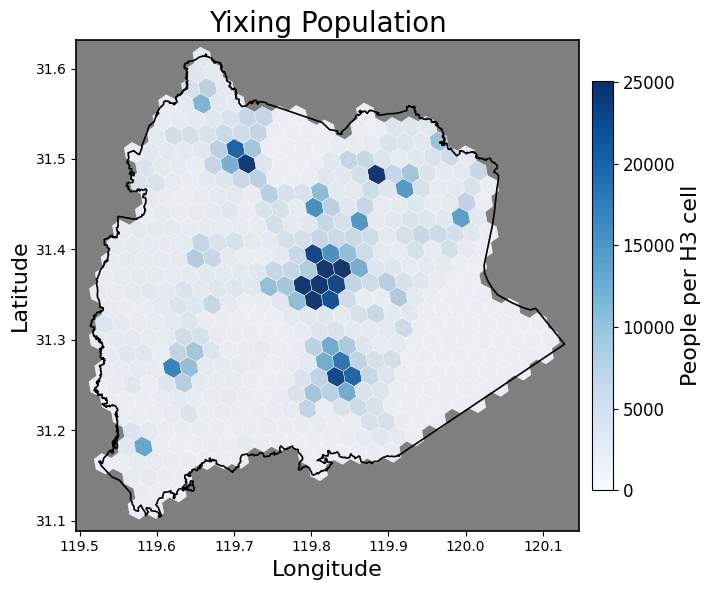

In [42]:
# 9) 转成 GeoDataFrame（完整 H3 六角形）
merged_full["geometry"] = merged_full["id"].apply(h3_to_polygon)
gdf_h3_full = gpd.GeoDataFrame(merged_full, geometry="geometry", crs="EPSG:4326")

# 10) 画图（用 gdf_h3_full，不要 clip）
fig, ax = plt.subplots(figsize=(8, 6))  # <-- 也放进“图面设定”风格里

ax.set_facecolor("#7f7f7f")

minx, miny, maxx, maxy = districts.total_bounds
pad_x = (maxx - minx) * 0.03
pad_y = (maxy - miny) * 0.03
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)

vmax = np.nanpercentile(gdf_h3_full["pop"].values, 99)

gdf_h3_full.plot(
    column="pop",
    ax=ax,
    cmap="Blues",
    alpha=0.9,
    edgecolor="white",
    linewidth=0.35,
    vmin=0,
    vmax=vmax,
    zorder=2
)

districts.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.2,
    zorder=3
)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color("black")

# Step 5: 圖面設定（统一字号）
ax.set_xlabel("Longitude", fontsize=16)
ax.set_ylabel("Latitude", fontsize=16)
ax.set_title("Yixing Population", fontsize=20)
ax.autoscale_view()

import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=0, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap="Blues", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("People per H3 cell", fontsize=16)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.tight_layout()

# 存成 PDF（建议 bbox_inches 防裁切）
plt.savefig("yixing_population.pdf", format="pdf", bbox_inches="tight")

plt.show()


In [43]:
merged_full.to_csv("pop_data.csv", index=False, encoding="utf-8-sig")
merged_full

,id,pop,geometry
0,87309e000ffffff,863.636780,POLYGON ((119.6978298323664 31.265919198810078...
1,87309e001ffffff,799.965454,"POLYGON ((119.7197854290453 31.26666040427787,..."
2,87309e002ffffff,661.780884,POLYGON ((119.69038621260309 31.24852833448515...
3,87309e003ffffff,645.614563,POLYGON ((119.71234246013611 31.24927361537663...
4,87309e004ffffff,2022.857788,POLYGON ((119.68331236232518 31.28256283166886...
...,...,...,...
511,87309ebb2ffffff,8597.009766,POLYGON ((119.73619383129055 31.50666997986254...
512,87309ebb3ffffff,21.597500,POLYGON ((119.75815963560419 31.50736611098085...
513,87309ebb4ffffff,5236.932129,POLYGON ((119.72912330131028 31.54059365702327...
514,87309ebb5ffffff,5462.749023,POLYGON ((119.7510942568113 31.541285631841006...
